In [1]:
import pandas as pd
import numpy as p
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('C:/Users/pinki/OneDrive/Desktop/Machine_learning_indetails/dataset/Mall_Customers.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
le = LabelEncoder()
df['Gender_Id'] = le.fit_transform(df['Gender'])

In [4]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)', 'Gender_Id'],
      dtype='object')

### Features

In [5]:
X = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Gender_Id']]

In [6]:
scaler = StandardScaler()
X_scale = scaler.fit_transform(X)

### Elbow Method

In [7]:
error_rate = []
k_range = range(1, 21)

In [8]:
for i in k_range:
    kmean = KMeans(n_clusters = i)
    kmean.fit_predict(X_scale)
    error_rate.append(kmean.inertia_)

Text(0.5, 1.0, 'Elbow Method - Choosing Optimal Number of Clusters')

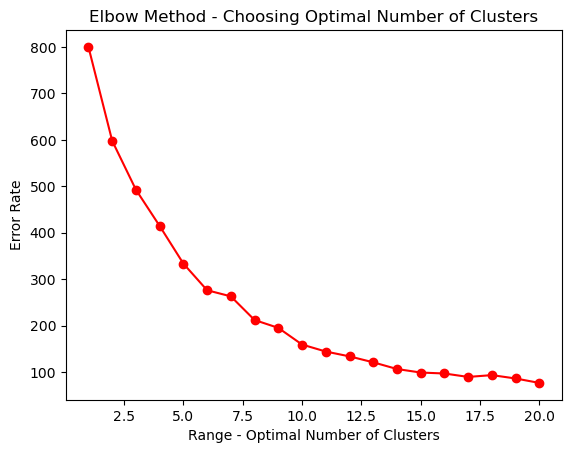

In [9]:
plt.plot(k_range, error_rate, color='red', marker='o')
plt.xlabel('Range - Optimal Number of Clusters')
plt.ylabel('Error Rate')
plt.title('Elbow Method - Choosing Optimal Number of Clusters')

In [10]:
k = 5
model = KMeans(n_clusters=k)
clusters = model.fit_predict(X_scale)
# df['clusters'] = clusters

In [22]:
sns.scatterplot(x=df['Annual Income (k$)'], y=df['Spending Score (1-100)'], hue=clusters, palette='viridis')
plt.close()

In [14]:
cluster = model.labels_
df['cluster'] = cluster

In [15]:
pair_plot = df

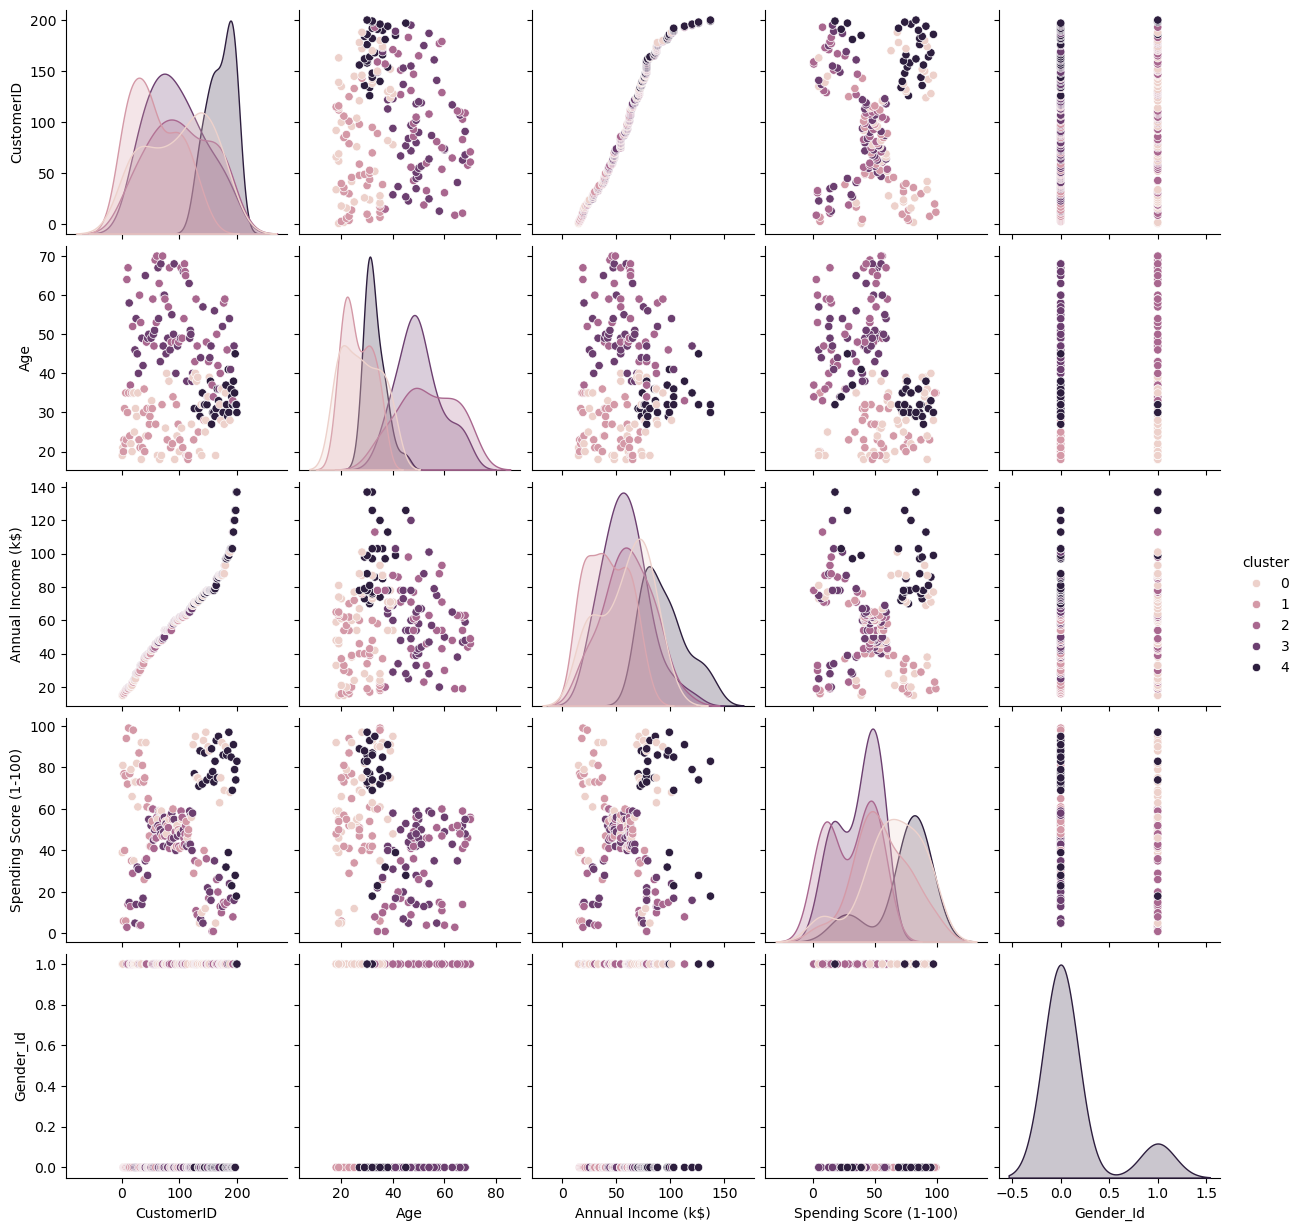

In [21]:
sns.pairplot(
    pair_plot,
    hue='cluster'
)
plt.savefig('pp.png')

In [23]:
total_customer = df.groupby('cluster')['CustomerID'].count().reset_index()
total_customer

,cluster,CustomerID
0,0,43
1,1,39
2,2,41
3,3,48
4,4,29
